# Applying Transfer Learning with EfficientNet-B0 (EfficientNet Model)

Now, we are moving into another convolutional neural network baseline, called EfficientNet-B0. While ResNet-18 is a classic baseline, EfficientNet-B0 appears as a more modern and efficiency-focused baseline. ResNet-18 works with standard, dense 2D convolutions. On the other hand, EfficientNet-B0 uses more efficient convolutional operations, which allows it to extract useful features while keeping the number of parameters relatively low.

An interesting fact is that EfficientNet-B0 has less than half the number of parameters compared to ResNet-18, but it can still run slower because of its more complex operations. Even so, both baselines are relatively fast, compact and inexpensive to run, while following two different philosophies for achieving lightweight computer vision. In light of all this, EfficientNet-B0's pre-trained weights may provide a strong starting point for our dataset, which we hope will result in higher performance. This model will be referred to as the **EfficientNet Model** from now on.

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform_transfer_train, get_transform_transfer_eval, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform_train = get_transform_transfer_train()
transform_eval = get_transform_transfer_eval()
dataset = get_data(transform_train)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomCrop(size=(200, 200), padding=None)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )

In [5]:
train_data, val_data, test_data = get_datasets(transform_train, transform_eval)

In [6]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [7]:
from src.models import get_efficientnet_b0

In [8]:
efficientnet_model = get_efficientnet_b0()
efficientnet_model.load_state_dict(torch.load('models/06_efficientnet_aug_sgd_momentum50.pth'))

<All keys matched successfully>

In [9]:
efficientnet_model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Evaluating Model

In [10]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [11]:
loss, accuracy, all_labels, all_predictions = evaluate_model(efficientnet_model, val_loader)

In [12]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 0.2280
Accuracy: 91.70%


Given the validation loss of 0.2280 and accuracy of 91.7%, we can see a small but meaningful improvement in both validation metrics with the EfficientNet Model compared to the ResNet Model. The validation loss dropped from 0.3771 to 0.2280, while the accuracy increased by almost 1%. As mentioned before, EfficientNet's complex operations tend to extract richer, high-quality features from images, allowing it to capture subtle details. This resulted in the best-performing model we tested, and we will proceed to evaluate it on the test set.

### - Confusion Matrix

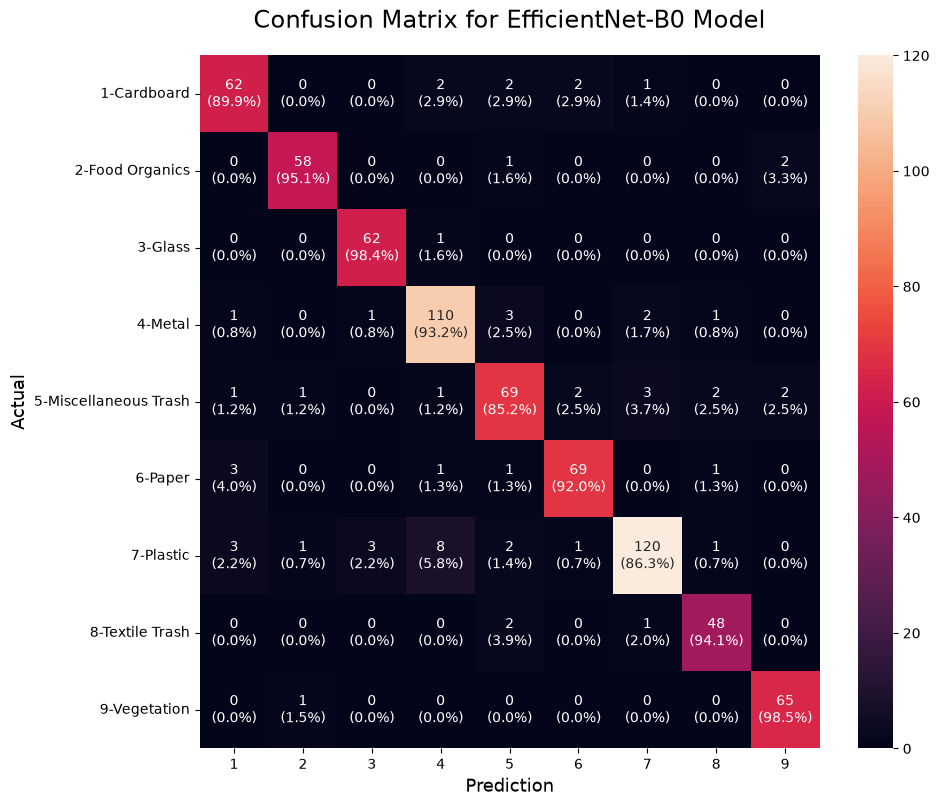

In [13]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for EfficientNet-B0 Model")

**Confusion Matrix Insights:**

. Again, basically all classes achieved very high accuracies.

. Plastic was able to increase its accuracy by 4% compared to the ResNet Model.

. The only notable misclassification was Plastic being categorized as Metal, but now only 5.8% of the time, a decrease of almost half compared to the ResNet Model.

. It is interesting to see that, although the accuracy of Miscellaneous Trash is 85.2%, it has mispredictions in all but one class. This behavior highlights again the diverse nature of the class.

. The rest of the misclassifications seem to be more spread out, without any noticeable pattern.

### - Inspecting misclassified images

Found 8 7-Plastic → 4-Metal


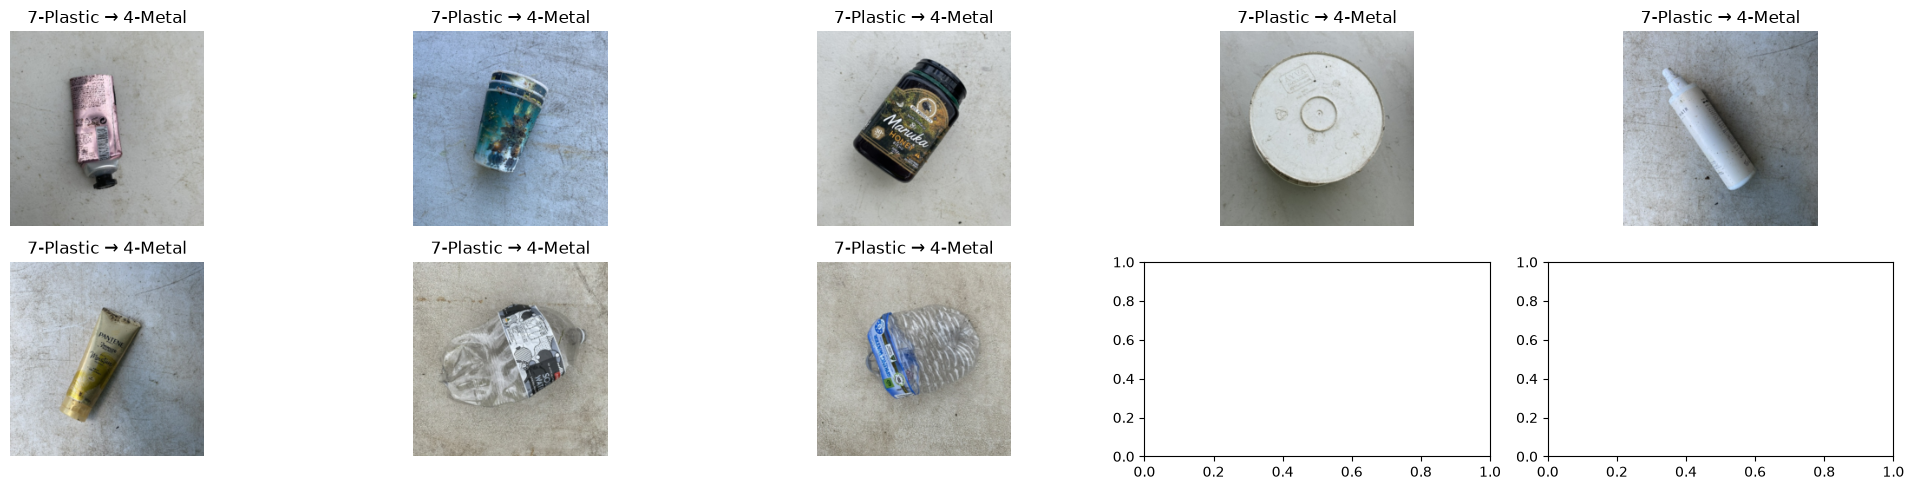

In [14]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "7-Plastic", "4-Metal", 
                  mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # 8 errors

## Test-set evaluation

Since this model was the one with the best validation metrics, it will be the only one assessed through the test set, which was completely unused and unseen until this point. The test results will be the ones reported as the final results for this project. To see an analysis between models, conclusions after experimenting with all models, and discussion of other techniques or experiments that could also have been meaningful for the model or project in general, please proceed to the next notebook about the final analysis. Here, we will discuss exclusively the test metrics with the EfficientNet Model.

### - Test Loss and Accuracy

In [15]:
test_loss, test_accuracy, all_labels_test, all_predictions_test = evaluate_model(efficientnet_model, test_loader)

In [16]:
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.2682
Test Accuracy: 92.53%


The test loss is 0.2682 and test accuracy is 92.53%. These results align well with the validation metrics and show no obvious degradation from validation to test performance, which is a good sign that the model generalizes well to the held-out data.

### - Test Precision, Recall and F1 Score

. Precision focuses exclusively on the predictions the model labeled as positive. It investigates, out of all the times the model predicted a class, how often it was correct.

. Recall measures the model's ability to find all the positive instances. It investigates, out of all the actual positive instances for a class, how many the model correctly identified.

. F1 Score is the harmonic mean of precision and recall, which balances the two into a single number.

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels_test, all_predictions_test, average="weighted")
recall = recall_score(all_labels_test, all_predictions_test, average="weighted")
f1 = f1_score(all_labels_test, all_predictions_test, average="weighted")

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Precision: 0.9265
Test Recall: 0.9253
Test F1 Score: 0.9251


The test precision is 0.9253, the test recall is 0.9253 and the test F1 score is 0.9251. The particularly nice thing here is that precision, recall and F1 score are all around 92.5%, which indicates that the model isn't achieving its accuracy by being disproportionately good at only a few classes.

In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels_test,
    all_predictions_test,
    target_names=dataset.classes
))

                       precision    recall  f1-score   support

          1-Cardboard       0.88      0.96      0.92        69
      2-Food Organics       0.94      0.97      0.95        62
              3-Glass       0.91      0.98      0.95        63
              4-Metal       0.92      0.93      0.93       119
5-Miscellaneous Trash       0.88      0.88      0.88        81
              6-Paper       0.93      0.93      0.93        75
            7-Plastic       0.97      0.88      0.92       138
      8-Textile Trash       0.94      0.88      0.91        51
         9-Vegetation       0.95      0.97      0.96        65

             accuracy                           0.93       723
            macro avg       0.92      0.93      0.93       723
         weighted avg       0.93      0.93      0.93       723



**Class-by-Class Test Metrics Insights:**

. The Vegetation, Food Organics, and Glass classes performed excellently, with an F1 Score of at least 0.95.

. Cardboard has a high recall (0.96) but a lower precision (0.88), meaning the model catches most cardboard images but sometimes incorrectly labels other materials as Cardboard.

. On the other hand, Plastic has a precision of 0.97 but only a recall of 0.88. This indicates that the model is usually right when it classifies an object as Plastic, but it is missing some actual Plastic images.

. The two weakest classes are Textile Trash and Miscellaneous Trash, with F1 Scores of 0.91 and 0.88, respectively. As we observed throughout the entire project, this is not surprising given that both classes are quite broad and heterogeneous.

### - Test Confusion Matrix

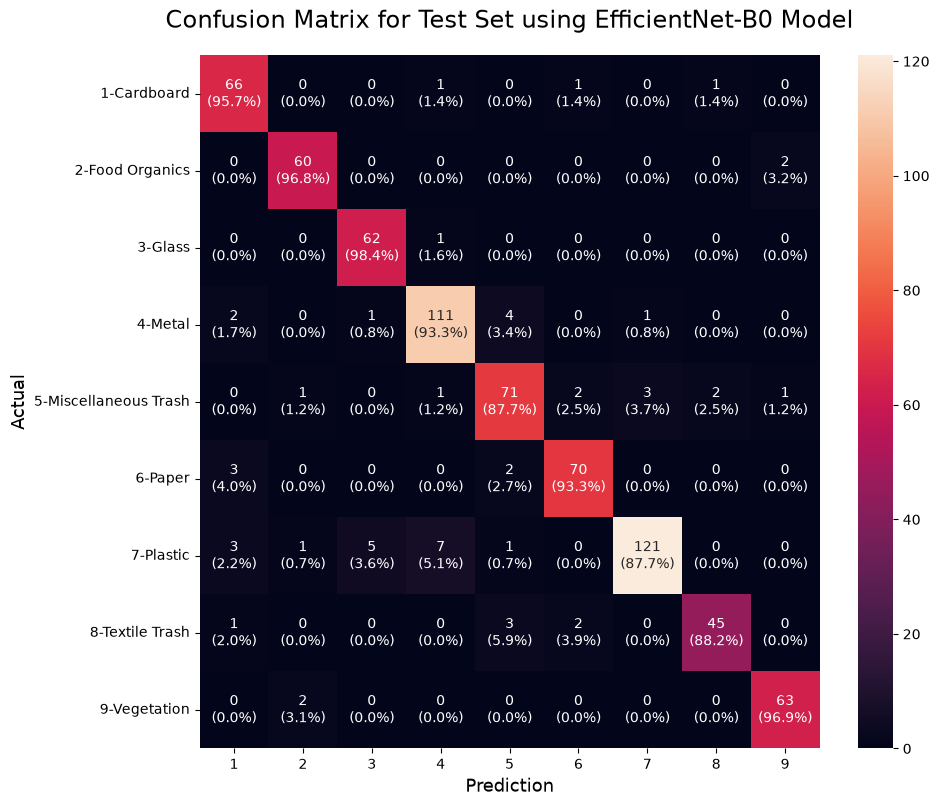

In [19]:
create_confusion_matrix(all_labels_test, all_predictions_test, dataset.classes, title="Confusion Matrix for Test Set using EfficientNet-B0 Model")

**Confusion Matrix For Test Set Insights:**

. All classes achieved very high accuracies, with 6 out of 9 achieving at least 93.3% accuracy.

. The only notable misclassification was Plastic being categorized as Metal or Glass, summing to 8.7% of the cases.

. The rest of the misclassifications seem to be more spread out, without any noticeable pattern.

### - Inspecting misclassified images

Found 7 7-Plastic → 4-Metal


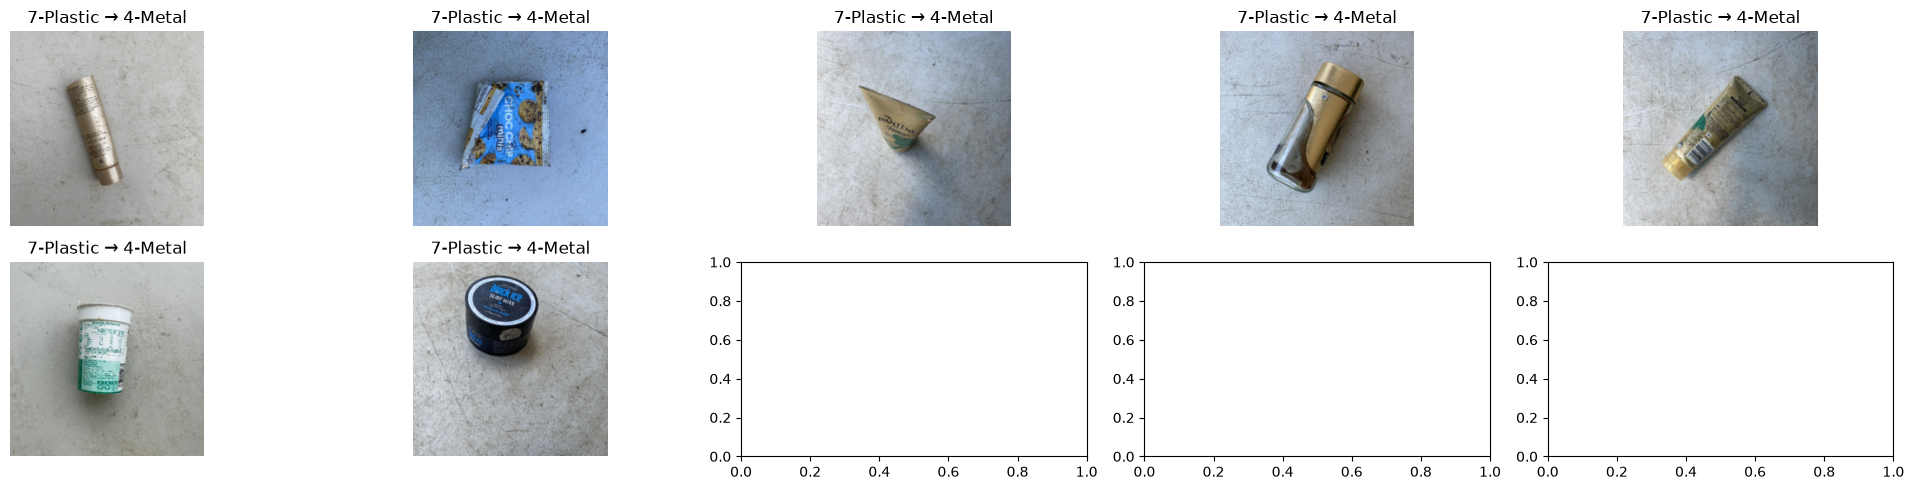

In [20]:
inspecting_images(dataset, test_data, all_labels_test, all_predictions_test, "7-Plastic", "4-Metal", 
                  mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # 7 errors

Found 5 7-Plastic → 3-Glass


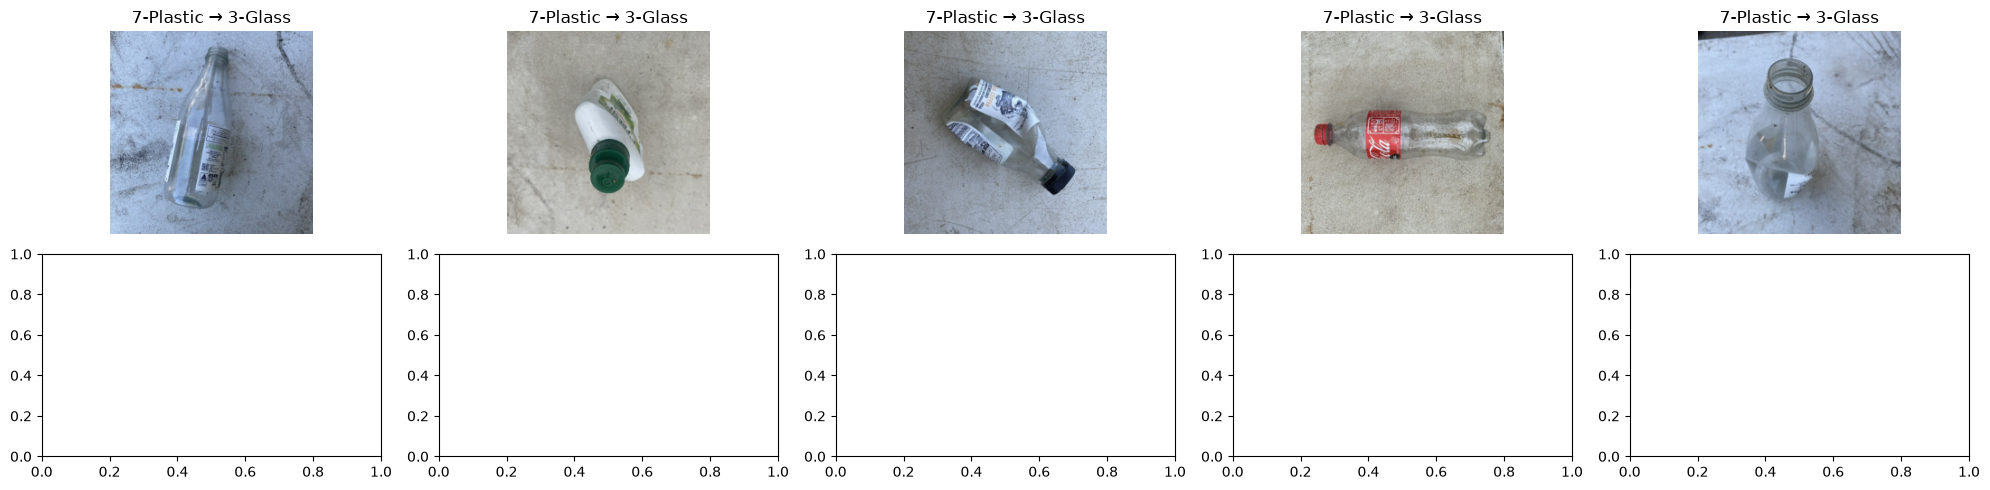

In [21]:
inspecting_images(dataset, test_data, all_labels_test, all_predictions_test, "7-Plastic", "3-Glass", 
                  mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) # 5 errors

**Misclassified Images for Test Set Insights:**  

. The cases in which the EfficientNet Model misclassified Plastic as Metal seemed to have in common the fact that the plastic objects were gold-colored, which may have falsely led the model to this confusion.

. Similarly, the cases in which the EfficientNet Model misclassified Plastic as Glass seemed to have in common the fact that the plastic objects were transparent, which may have falsely led the model to this confusion.